In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp

In [20]:
#@markdown Autor: Marvin A. Böttcher (2016) **[[Github](https://github.com/marvinboe/egtsimplex), [Webpage](http://web.evolbio.mpg.de/~boettcher//other/2016/egtsimplex.html)]**.
########################################
#    EGTsimplex
#    Copyright 2016 Marvin A. Böttcher
#
#    This program is free software: you can redistribute it and/or modify
#    it under the terms of the GNU General Public License as published by
#    the Free Software Foundation, either version 3 of the License, or
#    (at your option) any later version.
#
#    This program is distributed in the hope that it will be useful,
#    but WITHOUT ANY WARRANTY; without even the implied warranty of
#    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
#    GNU General Public License for more details.
#
#    You should have received a copy of the GNU General Public License
#    along with this program.  If not, see <http://www.gnu.org/licenses/>.
#########################################

import scipy.optimize
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np
import math
class simplex_dynamics:
    '''draws dynamics of given function and 
    corresponding fixed points into triangle'''
    #corners of triangle and calculation of points
    r0=np.array([0,0])
    r1=np.array([1,0])
    r2=np.array([1/2.,np.sqrt(3)/2.])
    corners =np.array([r0,r1,r2])
    triangle = tri.Triangulation(corners[:, 0], corners[:, 1])
    refiner = tri.UniformTriRefiner(triangle)
    trimesh = refiner.refine_triangulation(subdiv=5)
    trimesh_fine = refiner.refine_triangulation(subdiv=5)

    def __init__(self,fun):
        self.f=fun
        self.calculate_stationary_points()
        self.calc_direction_and_strength()

    #barycentric coordinates
    def xy2ba(self,x,y):
        corner_x=self.corners.T[0]
        corner_y=self.corners.T[1]
        x_1=corner_x[0]
        x_2=corner_x[1]
        x_3=corner_x[2]
        y_1=corner_y[0]
        y_2=corner_y[1]
        y_3=corner_y[2]
        l1=((y_2-y_3)*(x-x_3)+(x_3-x_2)*(y-y_3))/((y_2-y_3)*(x_1-x_3)+(x_3-x_2)*(y_1-y_3))
        l2=((y_3-y_1)*(x-x_3)+(x_1-x_3)*(y-y_3))/((y_2-y_3)*(x_1-x_3)+(x_3-x_2)*(y_1-y_3))
        l3=1-l1-l2
        return np.array([l1,l2,l3])

    def ba2xy(self,x):
        ### x: array of 3-dim ba coordinates
        ### corners: coordinates of corners of ba coordinate system
        x=np.array(x)
        # print(self.corners.shape)
        # print(self.corners.T)
        # print(x)
        return self.corners.T.dot(x.T).T


    def calculate_stationary_points(self):
        fp_raw=[]
        border=5 #don't check points close to simplex border
        delta=1e-12
        for x,y in zip(self.trimesh.x[border:-border], self.trimesh.y[border:-border]):
            start=self.xy2ba(x,y)
            fp_try=np.array([])

            sol=scipy.optimize.root(self.f,start,args=(0,),method="hybr",tol=1e-20)#,xtol=1.49012e-10,maxfev=1000
            if sol.success:
                fp_try=sol.x
                #check if FP is in simplex
                if not math.isclose(np.sum(fp_try), 1.,abs_tol=2.e-2):
                    continue
                if not np.all((fp_try>-delta) & (fp_try <1+delta)):#only if fp in simplex
                    continue
            else:
                continue
            #only add new fixed points to list
            if not np.array([np.allclose(fp_try,x,atol=1e-3) for x in fp_raw]).any():
                    fp_raw.append(fp_try.tolist())
        #add fixed points in correct coordinates to fixpoints list
        fp_raw=np.array(fp_raw)
        if fp_raw.shape[0]>0:
            self.fixpoints=self.corners.T.dot(np.array(fp_raw).T).T
        else:
            self.fixpoints=np.array([])

    def calc_direction_and_strength(self):
        direction= [self.f(self.xy2ba(x,y),0) for x,y in zip(self.trimesh.x, self.trimesh.y)]
        self.direction_norm=np.array([self.ba2xy(v)/np.linalg.norm(v) if np.linalg.norm(v)>0 else np.array([0,0]) for v in direction])
        self.direction_norm=self.direction_norm
        #print(direction_ba_norm)
        self.pvals =[np.linalg.norm(v) for v in direction]
        self.direction=np.array([self.ba2xy(v) for v in direction])
        
    def plot_simplex(self,ax,cmap='inferno',typelabels=["A","B","C"],fixed=True,**kwargs):

        ax.triplot(self.triangle,linewidth=0.8,color="black")
        ax.tricontourf(self.trimesh, self.pvals, alpha=0, cmap=cmap,**kwargs)

        #arrow plot options:
        # Q = ax.quiver(self.trimesh.x, self.trimesh.y, self.direction_norm.T[0],self.direction_norm.T[1],self.pvals,angles='xy',pivot='mid',  cmap=cmap)#pivot='tail',
        Q = ax.quiver(self.trimesh.x, self.trimesh.y, self.direction_norm.T[0],self.direction_norm.T[1],angles='xy',pivot='mid')#pivot='tail')#
        # Q = ax.quiver(self.trimesh.x, self.trimesh.y, self.direction.T[0],self.direction.T[1],angles='xy',pivot='mid')#pivot='tail')#


        ax.axis('equal')
        ax.axis('off')
        margin=0.01
        ax.set_ylim(ymin=-margin,ymax=self.r2[1]+margin)
        ax.set_xlim(xmin=-margin,xmax=1.+margin)
        #timescatter=ax.scatter(points[::5,0],points[::5,1],c=t[::5],linewidth=0.0,cmap='viridis',alpha=.5)
        if self.fixpoints.shape[0]>0:
            ax.scatter(self.fixpoints[:,0],self.fixpoints[:,1],c="black",s=70,linewidth=0.3)
        if(fixed==True):
            for i in self.fixpoints:
                x=i[0]
                y=i[1]
                a,b,c=self.xy2ba(x,y)
                # ax.annotate("({:.2f},{:.2f},{:.2f})".format(abs(a),abs(b),abs(c)),(i[0],i[1]))
        #fig.colorbar(timescatter,label="time")
        ax.annotate(typelabels[0],(0,0),xytext=(-0.0,-0.02),horizontalalignment='center',va='top')
        ax.annotate(typelabels[1],(1,0),xytext=(1.0,-0.02),horizontalalignment='center',va='top')
        ax.annotate(typelabels[2],self.corners[2],xytext=self.corners[2]+np.array([0.0,0.02]),horizontalalignment='center',va='bottom')

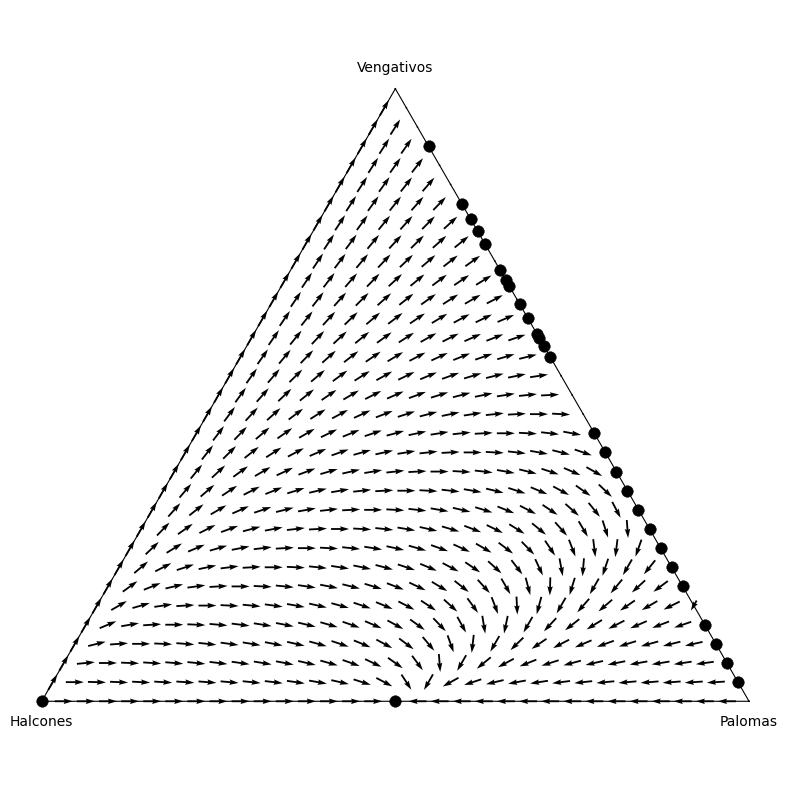

In [21]:
#define function of x=[x0,x1,x2] and t to plot dynamics on simplex
def HPB(x,t):
    global G
    global C
    A=np.array([[(G-C)/2,G,G],[0,G/2,0],[0,G,G/2]])
    phi=(x.dot(A.dot(x)))
    x0dot=x[0]*(A.dot(x)[0]-phi)
    x1dot=x[1]*(A.dot(x)[1]-phi)
    x2dot=x[2]*(A.dot(x)[2]-phi)
    return [x0dot,x1dot,x2dot]


def HPV(x,t):
    global G
    global C
    A=np.array([[(G-C)/2,G,(G-C)/2],[0,G/2,G/2],[(G-C)/2,G/2,G/2]])
    phi=(x.dot(A.dot(x)))
    x0dot=x[0]*(A.dot(x)[0]-phi)
    x1dot=x[1]*(A.dot(x)[1]-phi)
    x2dot=x[2]*(A.dot(x)[2]-phi)
    return [x0dot,x1dot,x2dot]


#initialize simplex_dynamics object with function

fig,ax=plt.subplots(1,1,figsize=(8,8))
s=0
G=1
C=2
s=0
dynamics=simplex_dynamics(HPV)
dynamics.plot_simplex(ax,typelabels=["Halcones","Palomas","Vengativos"])
plt.tight_layout()
plt.savefig("Simplex2.pdf")
plt.show()